Loading checkpoint from 'Model_Checkpoints/five_conv_model.tar'...
Metrics plotted and saved to 'output/' + model_name + '_metrics.png'


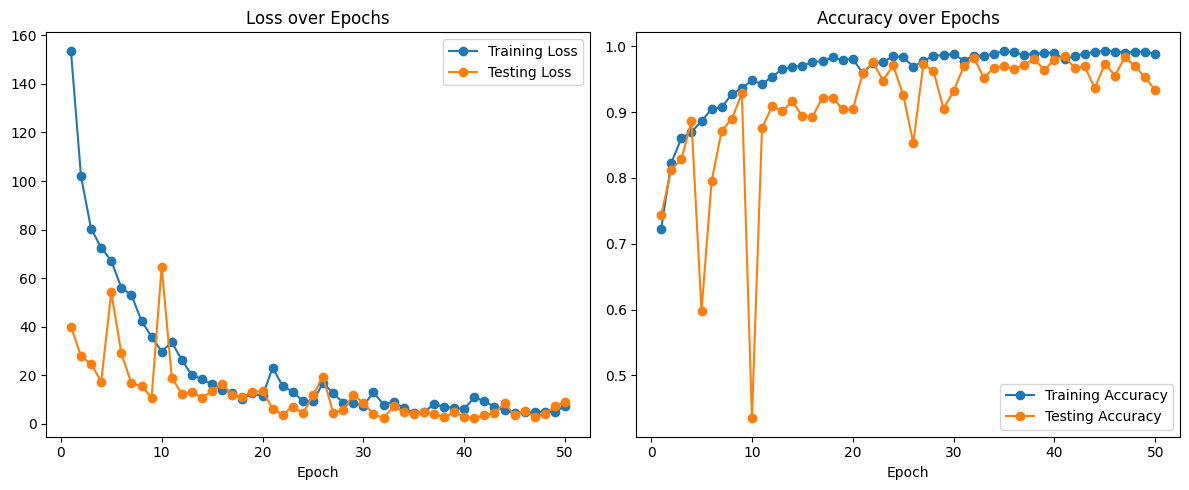

In [5]:
import torch
import matplotlib.pyplot as plt
import os

model_name = "five_conv_model.tar"

checkpoint_path = os.path.join("Model_Checkpoints", model_name)

if not os.path.exists(checkpoint_path):
    print(f"Error: Could not find checkpoint at '{checkpoint_path}'")
else:
    print(f"Loading checkpoint from '{checkpoint_path}'...")
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    
    train_loss = checkpoint.get('train_loss')
    test_loss = checkpoint.get('test_loss')
    train_acc = checkpoint.get('train_acc')
    test_acc = checkpoint.get('test_acc')
    epoch = checkpoint.get('epoch', 'Unknown')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Check if they are lists (from tracking over epochs) or scalars
    if isinstance(train_loss,(list, tuple)):
        # Plot curves
        epochs_range = range(1, len(train_loss) + 1)
        axes[0].plot(epochs_range, train_loss, label='Training Loss', marker='o')
        if isinstance(test_loss, (list, tuple)):
            axes[0].plot(epochs_range, test_loss, label='Testing Loss', marker='o')
        axes[0].set_xlabel('Epoch')
        axes[0].set_title('Loss over Epochs')
        axes[0].legend()
        
        if isinstance(train_acc, (list, tuple)):
            axes[1].plot(epochs_range, train_acc, label='Training Accuracy', marker='o')
        if isinstance(test_acc, (list, tuple)):
            axes[1].plot(epochs_range, test_acc, label='Testing Accuracy', marker='o')
        axes[1].set_xlabel('Epoch')
        axes[1].set_title('Accuracy over Epochs')
        axes[1].legend()
    else:
        # Plot bar chart for scalar values
        axes[0].bar(['Training', 'Testing'], [train_loss or 0, test_loss or 0], color=['blue', 'orange'])
        axes[0].set_title(f'Loss at Epoch {epoch}')
        axes[0].set_ylabel('Loss')
        
        axes[1].bar(['Training', 'Testing'], [train_acc or 0, test_acc or 0], color=['blue', 'orange'])
        axes[1].set_title(f'Accuracy at Epoch {epoch}')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_ylim(0, 1.05)
        
    plt.tight_layout()
    plt.savefig('output/' + model_name + '_metrics.png')
    print("Metrics plotted and saved to 'output/' + model_name + '_metrics.png'")
